<a href="https://colab.research.google.com/github/solomeya12345-code/python_for_data_analitic/blob/main/Homework_4_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

У цьому домашньому завданні ми продовжуємо працювати з набором даних `Yulu`, з яким почали працювати в "hw 4.3. Робота з DataFrame. Діаграма розсіювання.". Фокус цього ДЗ в тому, аби будувати візуалізації використовуючи методи pandas.DataFrame. Це дозволяє будувати візуалізації ще швидше.

Документація до тої частини бібліотеки, з якою тут працюємо

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html

### Профіль колонок набору даних:

- **datetime**: дата та час зібрані погодинно
- **season**: сезон (1: весна, 2: літо, 3: осінь, 4: зима)
- **holiday**: чи є день святковим (витягнуто з http://dchr.dc.gov/page/holiday-schedule)
- **workingday**: якщо день не є вихідним або святковим, то позначається як 1, в іншому випадку – 0.
- **weather**:
  1. Ясно, Мало хмарно, частково хмарно
  2. Туман + Хмарно, Туман + Розірвані хмари, Туман + Мало хмарно, Туман
  3. Легкий сніг, Легкий дощ + Гроза + Розсіяні хмари, Легкий дощ + Розсіяні хмари
  4. Сильний дощ + Крижані кулі + Гроза + Туман, Сніг + Туман
- **temp**: температура в градусах Цельсія
- **atemp**: як відчувається температура в градусах Цельсія
- **humidity**: вологість
- **windspeed**: швидкість вітру
- **casual**: кількість неформальних користувачів
- **registered**: кількість зареєстрованих користувачів
- **count**: загальна кількість велосипедів, взятих в оренду, включаючи неформальних та зареєстрованих користувачів

0. Імпортуйте бібліотеки `matplotlib.pyplot` та `pandas`.  Завантажте дані з файла yulu_rental.csv у pandas.DataFrame df.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv('drive/MyDrive/Python_for_DA/yulu_rental.csv')

1.1. Користуючись групою методів `pandas.plot` побудуйте гістограму кількості зареєстрованих користувачів з налаштуваннями за замовченням (тобто без жодних додаткових параметрів).

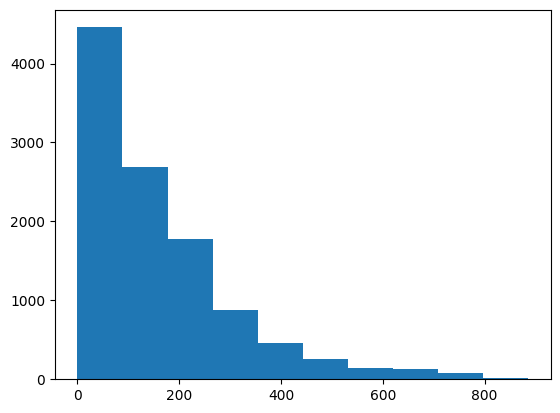

In [5]:
plt.hist(df['registered']);

Або:

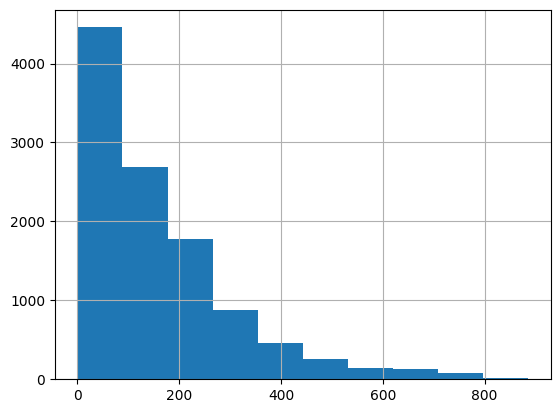

In [72]:
df.registered.hist();

1.2. Побудуйте гістограму для цього ж показника, але задайте кількість бінів рівну 30 і задайте прозорість 0.5. Додайте підписи за осями ОХ і ОУ, а також назву діаграмі. Опишіть свої спостереження. Що бачите? Чому дані можуть мати такий розподіл?

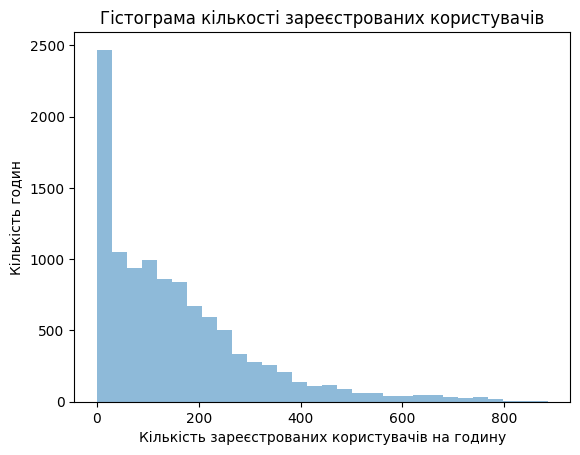

In [18]:
plt.hist(df.registered, bins=30, alpha=.5)
plt.xlabel('Кількість зареєстрованих користувачів на годину')
plt.ylabel('Кількість годин')
plt.title('Гістограма кількості зареєстрованих користувачів');

Або:

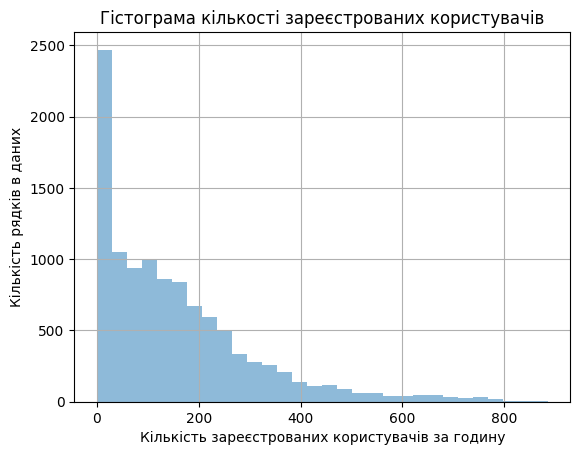

In [73]:
df.registered.hist(bins=30, alpha=0.5)
plt.title('Гістограма кількості зареєстрованих користувачів')
plt.xlabel('Кількість зареєстрованих користувачів за годину')
plt.ylabel('Кількість рядків в даних');

На гістограмі видно, що найбільша кількість годин припадає на найменшу кількість зареєстрованих користувачів, і збільшенню кількості користувачів на одну годину відповідає менші кільуість годин.
Такий розподіл даних може бути тому, що вночі, наприклад, користувачів немає, і ці години рахуються в статистику. А така ситуація, що за одну годину буде більше 800 користувачів, дуже рідкісна.

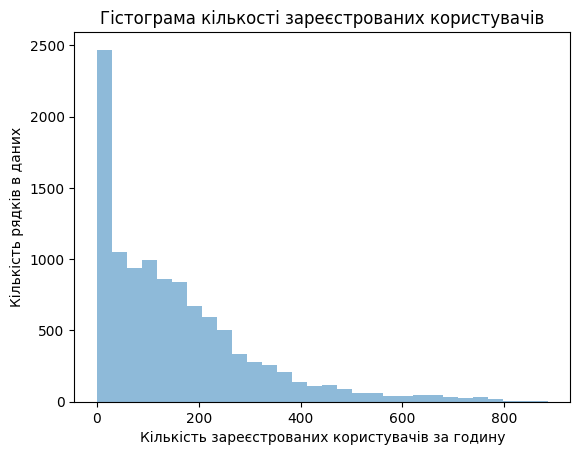

In [74]:
# ще один варіант виконання
df.registered.plot(kind='hist', bins=30, alpha=0.5,
                   title='Гістограма кількості зареєстрованих користувачів',
                   xlabel='Кількість зареєстрованих користувачів за годину',
                   ylabel='Кількість рядків в даних');

Має вийти щось таке (може бути без сітки):

![](https://drive.google.com/uc?export=view&id=1Pb3UD8cmg_V0LLf8A4feOepTDXMqEAf8)


**Відповідь на питання**

Бачимо, що більшість значень зосереджена в лівій частині графіка, тобто більшість годин має низьку кількість зареєстрованих поїздок, в тому числі 0, що нормально, адже є години (імовірно, нічні, або малопопулярні), коли не було жодного зареєстрованого користувача.

Розподіл схожий на експоненційний, де значення швидко зменшуються зі збільшенням кількості зареєстрованих користувачів. Це може бути ознакою того, що велика кількість поїздок відбувається в певні "пікові" періоди (можливо, час пік вранці та вечорі), а в інший час — активність користувачів значно знижується.

Можливі причини такого розподілу:

- **Сезонність та погода**: В певні пори року або при несприятливій погоді користувачі менш активні.
- **Робочий графік**: Користувачі можуть частіше використовувати велосипеди для добирання до місця роботи чи навчання, що призводить до піків в певні години.
- **Розташування станцій**: Можливо, деякі станції мають вищу активність через своє розташування у місцях з високою прохідністю людей.

Далі було б цікаво дослідити, в які саме години і які саме станції мають 0 зареєстрованих поїздок і що ми можемоо зробити з цим.

--------

Перетворимо колонку `datetime` на тип даних `pd.datetime` - це нам доопоможе в подальшій роботі. Просто запустіть колонку нижче і занатуйте собі цей метод роботи з колонкою, в якій міститься дата і час.

In [19]:
df['datetime'] = pd.to_datetime(df.datetime)

І створимо нову колонку `dayofweek` для того, аби дослідити детальніше, коли у нас немає поїздок.

In [21]:
df['dayofweek'] = df.datetime.dt.day_of_week

Переглянемо значення в колонкці. Колонка dayofweek містить числа від 0 до 6 включно, де 0 відповідає понеділку.

In [22]:
df[['datetime','dayofweek']][df.dayofweek==0].head()

,datetime,dayofweek
47,2011-01-03 00:00:00,0
48,2011-01-03 01:00:00,0
49,2011-01-03 04:00:00,0
50,2011-01-03 05:00:00,0
51,2011-01-03 06:00:00,0


2. Проведемо аналіз нульової активності зареєстрованих користувачів за днями тижня. Для цього
  1. Виберіть з набору даних усі записи, де кількість зареєстрованих користувачів дорівнює 0. Групуйте ці записи за днями тижня (`dayofweek`) та обчисліть кількість нульових записів для кожного дня.
  2. Після групування, використайте графік типу "bar" для візуалізації результатів. Кожна смужка на графіку має відображати кількість записів у даних для цього дня тижня, коли не було зареєстровано жодної поїздки користувачами.

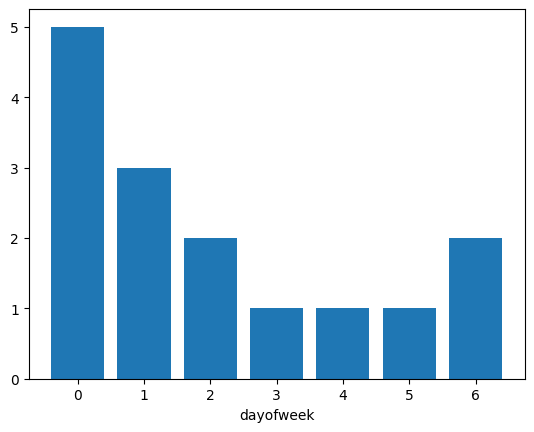

In [48]:
zero_reg = df[df.registered == 0].groupby('dayofweek')['registered'].count()
plt.bar(zero_reg.index, zero_reg.values)
plt.xlabel('dayofweek');

Або:

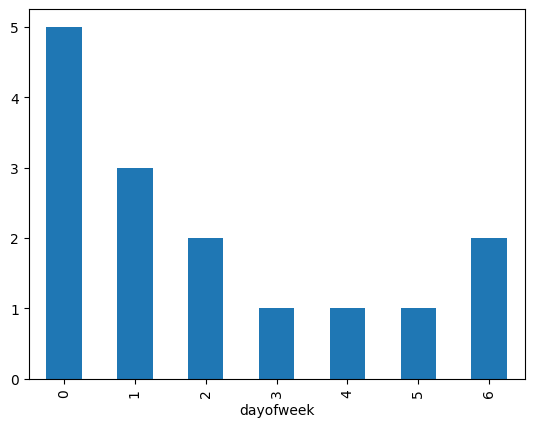

In [75]:
df[df.registered==0].groupby('dayofweek').size().plot.bar();

Очікуваний результат:

![](https://drive.google.com/uc?export=view&id=1FXNzMa7rTdBQDwXSQfPTtPX5CHZK9A4X)

3. Проведемо аналіз загальної кількості зареєстрованих кристувачів за різними погодними умовами.
Згрупуйте всі дані за погодними умовами і визначте суму кількості зареєстрованих користувачів для кожної погодньої умови.
Побудуйте стовпачасту діаграму, які відобразить результат обчислень.
Зверніться до опису даних та дайте відповідь: чи побудована візуалізація має логічний сенс з точки зору опису даних.

In [52]:
weather_reg = df.groupby('weather').sum(['registered'])
weather_reg

,season,holiday,workingday,temp,atemp,humidity,windspeed,casual,registered,count,dayofweek
weather,,,,,,,,,,,
1,17959,204,4839,147846.82,172565.755,407907,92723.1626,289900,1186163,1476063,22176
2,7171,92,1937,55587.80,65387.220,195831,34517.8506,87246,419914,507160,8199
3,2156,15,635,16790.32,19544.905,69872,12087.2020,14983,87106,102089,2435
4,1,0,1,8.20,11.365,86,6.0032,6,158,164,0


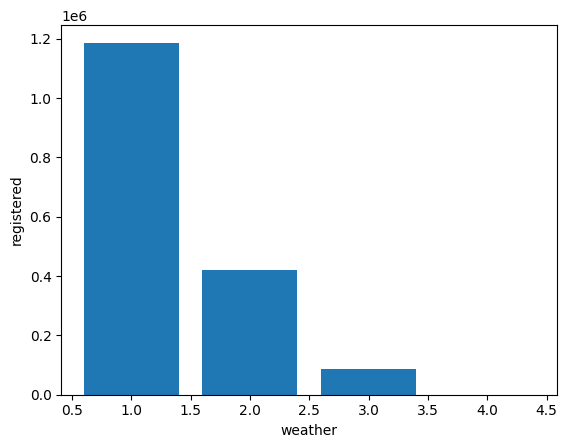

In [58]:
plt.bar(weather_reg.index, weather_reg.registered)
plt.xlabel('weather')
plt.ylabel('registered');

Побудована візуалізація має логічний сенс з точки зору опису даних.


Або:

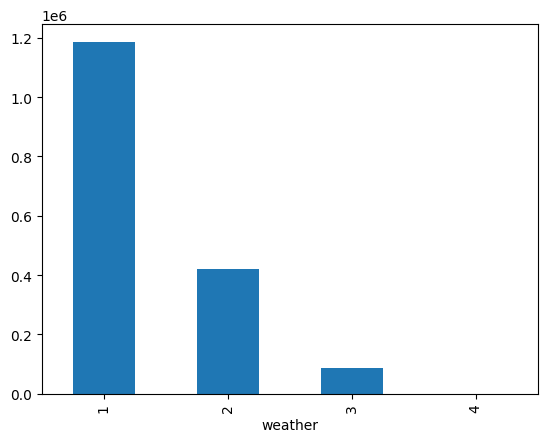

In [76]:
df.groupby('weather')['registered'].sum().plot.bar();

**Відповідь на питання**

Маємо наступний опис колонки з погодними умовами:

- **weather**:
  1. Ясно, Мало хмарно, частково хмарно
  2. Туман + Хмарно, Туман + Розірвані хмари, Туман + Мало хмарно, Туман
  3. Легкий сніг, Легкий дощ + Гроза + Розсіяні хмари, Легкий дощ + Розсіяні хмари
  4. Сильний дощ + Крижані кулі + Гроза + Туман, Сніг + Туман

Загалом, чим вища цифра показника погодних умов, тим видо, що менше велосипедів було арендовано.
Бачимо, що сума для погодних умов #4 - 0, що логічно, за таких умов люди не хочуть брати велосипеди в аренду.
Діаграма має логічний сенс.

4. Користуючись групою методів pandas.plot побудуйте діаграму розсіювання (scatter plot) між вологістю і кількістю зареєстрованих користувачів. Встановіть прозорість на 0.5, а також налаштуйте діаграму так, аби колір кожної точки відповідав значенню температури за відчуттями (`atemp`).

Проаналізуйте графік, що спостерігаєте?

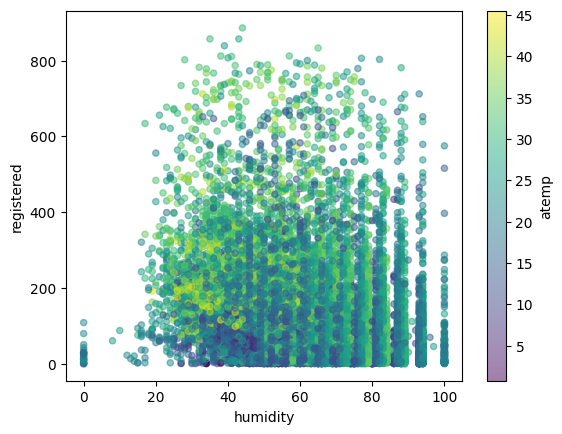

In [71]:
plt.scatter(df['humidity'], df['registered'], alpha=0.5,
            s=20, c=df.atemp)
plt.xlabel('humidity')
plt.ylabel('registered')
plt.colorbar().set_label('atemp');

Або:

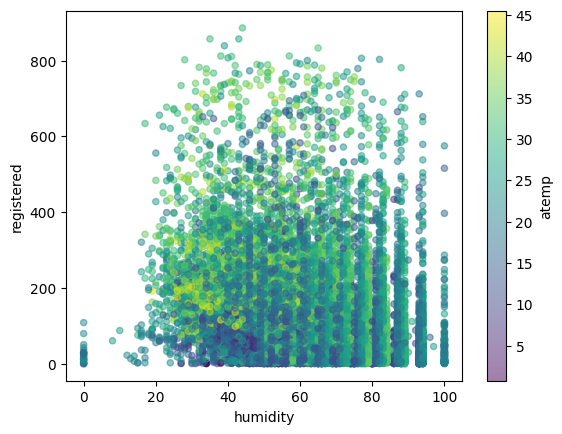

In [77]:
df.plot.scatter(x='humidity', y='registered', alpha=0.5, c='atemp');

Очікуваний результат:

![](https://drive.google.com/uc?export=view&id=1trepX8z23YwyP9P8cAko9IzwOZkvLo8y)

**Відповідь на питання**

Спостереження з графіку:

Кількість зареєстрованих користувачів: Існує широкий діапазон кількості зареєстрованих користувачів, який сягає від нуля до близько 800, з великою кількістю точок, що розташовані ближче до нижньої частини осі Y.

Вологість: Точки на графіку розподілені по всьому діапазону вологості від низької до 100%. Проте, здається, що немає явного тенденції, яка б вказувала на зростання або зниження кількості зареєстрованих користувачів залежно від рівня вологості.

Відчувана температура: Кольорове кодування вказує на відчувану температуру, яка варіюється від близько 5 до 45 градусів. Можна побачити, що при вищих відчуваних температурах кількість зареєстрованих користувачів здається більшою, особливо в середньому діапазоні вологості.

Концентрація точок: Є деяка концентрація точок у середньому діапазоні вологості, що може свідчити про популярніші умови для велосипедних поїздок.

З цих спостережень можна зробити припущення, що попит на велосипеди не є прямо залежним від вологості, але певні умови, які включа